# Defense demo: from a model to executable Qiskit, on Aer and on real hardware

In [14]:
import sys, asyncio, re, concurrent.futures
import pathlib
REPO_ROOT = pathlib.Path.cwd().resolve()
while not (REPO_ROOT / "app").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from io import StringIO
from contextlib import redirect_stdout
from collections import defaultdict, OrderedDict

from openqasm3.parser import parse
from app.openqasm3.universal_transpiler import UniversalTranspiler
from app.openqasm3.qiskit_provider import QiskitProvider
from app.model.CompileRequest import CompileRequest
from app.transformation_manager import MergingProcessor
from app.enricher import Enricher
from app.enricher.gates import GateEnricherStrategy
from app.enricher.measure import MeasurementEnricherStrategy
from app.enricher.literals import LiteralEnricherStrategy
from app.enricher.splitter import SplitterEnricherStrategy
from app.enricher.merger import MergerEnricherStrategy
from app.config import Settings
from qiskit.visualization import plot_histogram


def to_qiskit(qasm):
    """The exporter alone: OpenQASM 3 -> Qiskit source."""
    return UniversalTranspiler(QiskitProvider()).visit_Program(parse(qasm))


def _readable(code):
    """Rename the pipeline's leqo_<md5> identifiers to short names tied to the model nodes."""
    node, owner = "prog", OrderedDict()
    for line in code.splitlines():
        m = re.match(r"\s*'# Start node (.+)'\s*$", line)
        if m:
            node = m.group(1)
        for h in re.findall(r"[0-9a-f]{32}", line):
            owner.setdefault(h, node)
    seen, token = defaultdict(int), {}
    for h, nd in owner.items():
        i = seen[nd]; seen[nd] += 1
        token[h] = nd if i == 0 else f"{nd}_{i}"
    out = re.sub(r"(?:leqo_[0-9a-f]{32}_)+",
                 lambda m: token[re.findall(r"[0-9a-f]{32}", m.group(0))[-1]] + "_", code)
    out = out.replace("leqo_reg", "qreg")
    return re.sub(r"(?m)^(\s*)'(# (?:Start|End) node .+)'\s*$", r"\1\2", out)


def pipeline_to_qiskit(request):
    """The full backend pipeline: a model graph -> readable, executable Qiskit."""
    enricher = Enricher(LiteralEnricherStrategy(), MeasurementEnricherStrategy(),
                        SplitterEnricherStrategy(), MergerEnricherStrategy(), GateEnricherStrategy())

    async def go():
        proc = MergingProcessor.from_compile_request(
            CompileRequest.model_validate(request), enricher, Settings())
        return await proc.process()

    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as ex, redirect_stdout(StringIO()):
        code = ex.submit(lambda: asyncio.run(go())).result()   # run async off the kernel loop
    return _readable(code)


def run_source(src):
    ns = {}
    with redirect_stdout(StringIO()):
        exec(src, ns)
    return ns.get("counts"), ns.get("qc")


def out_marginal(counts):
    m = {}
    for k, v in counts.items():
        m[k.split()[0]] = m.get(k.split()[0], 0) + v
    return m


print("ready")

ready


## Teleportation: a model through the full pipeline to execution
The model is a node-and-edge graph. The backend pipeline lowers it to Qiskit; the `# Start node` comments show each model node in the generated program.

In [ ]:
TELEPORT = {
    "metadata": {"version": "1.0.0", "name": "Teleportation", "description": "teleport |1>", "author": ""},
    "compilation_target": "qiskit",
    "nodes": [
        {"id": "q0", "type": "qubit"}, {"id": "q1", "type": "qubit"}, {"id": "q2", "type": "qubit"},
        {"id": "xprep", "type": "gate", "gate": "x"},
        {"id": "h1", "type": "gate", "gate": "h"},
        {"id": "cxbell", "type": "gate", "gate": "cnot"},
        {"id": "cxbm", "type": "gate", "gate": "cnot"},
        {"id": "h0", "type": "gate", "gate": "h"},
        {"id": "m1", "type": "measure", "indices": [0]},
        {"id": "m0", "type": "measure", "indices": [0]},
        {"id": "if1", "type": "if-then-else", "condition": "m1 == 1",
         "thenBlock": {"nodes": [{"id": "gx", "type": "gate", "gate": "x"}],
                       "edges": [{"source": ["if1", 1], "target": ["gx", 0]},
                                 {"source": ["gx", 0], "target": ["if1", 1]}]},
         "elseBlock": {"nodes": [], "edges": [{"source": ["if1", 1], "target": ["if1", 1]}]}},
        {"id": "if2", "type": "if-then-else", "condition": "m0 == 1",
         "thenBlock": {"nodes": [{"id": "gz", "type": "gate", "gate": "z"}],
                       "edges": [{"source": ["if2", 1], "target": ["gz", 0]},
                                 {"source": ["gz", 0], "target": ["if2", 1]}]},
         "elseBlock": {"nodes": [], "edges": [{"source": ["if2", 1], "target": ["if2", 1]}]}},
        {"id": "mout", "type": "measure", "indices": [0]},
    ],
    "edges": [
        {"source": ["q0", 0], "target": ["xprep", 0]},
        {"source": ["xprep", 0], "target": ["cxbm", 0]},
        {"source": ["cxbm", 0], "target": ["h0", 0]},
        {"source": ["h0", 0], "target": ["m0", 0]},
        {"source": ["q1", 0], "target": ["h1", 0]},
        {"source": ["h1", 0], "target": ["cxbell", 0]},
        {"source": ["cxbell", 0], "target": ["cxbm", 1]},
        {"source": ["cxbm", 1], "target": ["m1", 0]},
        {"source": ["q2", 0], "target": ["cxbell", 1]},
        {"source": ["cxbell", 1], "target": ["if1", 1]},
        {"source": ["if1", 1], "target": ["if2", 1]},
        {"source": ["if2", 1], "target": ["mout", 0]},
        {"source": ["m1", 0], "target": ["if1", 0], "identifier": "m1"},
        {"source": ["m0", 0], "target": ["if2", 0], "identifier": "m0"},
    ],
}

# Live path: run the program the modeler generated, pre-saved and tested in demo/modeler_teleport.py.
# If that file is missing, fall back to compiling the built-in model. Both produce the same teleportation.
_prog = REPO_ROOT / "demo" / "modeler_teleport.py"
if _prog.exists():
    tele_src = _prog.read_text()
    print("using the modeler-generated program: demo/modeler_teleport.py")
else:
    tele_src = pipeline_to_qiskit(TELEPORT)
    print("using the built-in backup model")
counts, qc = run_source(tele_src)


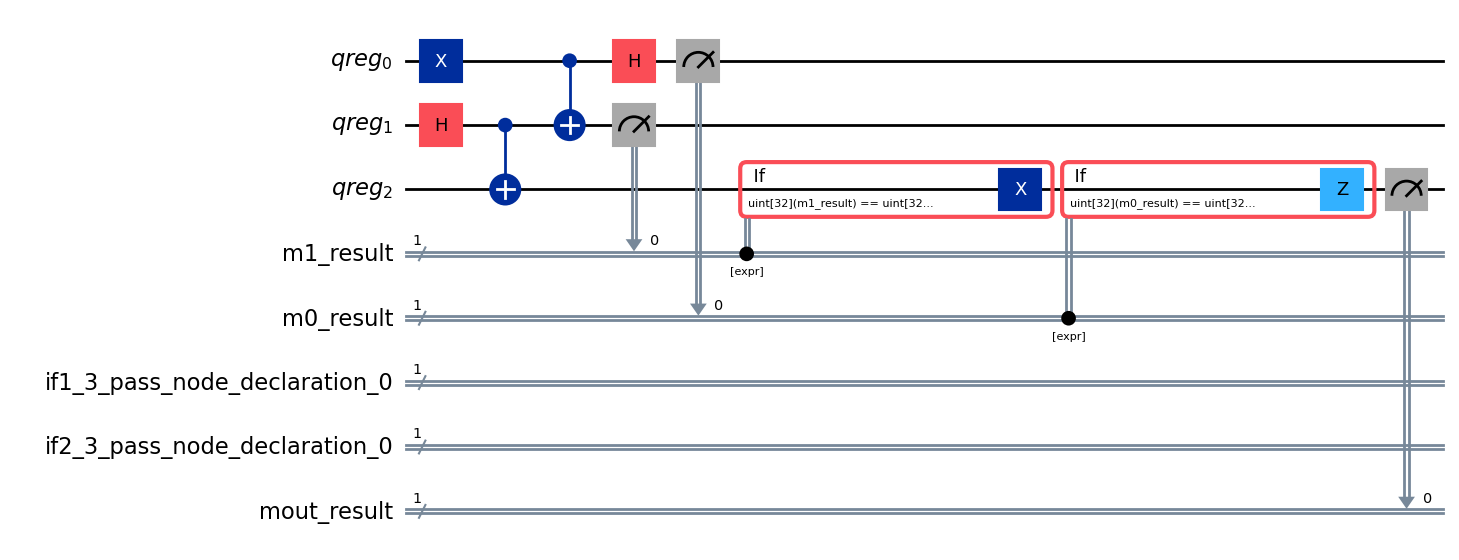

In [16]:
qc.draw("mpl")


In [17]:
print(tele_src)


from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.classical import types
from qiskit_aer import AerSimulator
import qiskit.circuit.classical.expr as expr
qc = QuantumCircuit()
inputs_list = []
qreg = QuantumRegister(3, 'qreg')
qc.add_register(qreg)
# Start node q0
q0_literal = [qreg[0]]
q0_out = q0_literal
# End node q0
# Start node q1
q1_literal = [qreg[1]]
q1_out = q1_literal
# End node q1
# Start node q2
q2_literal = [qreg[2]]
q2_out = q2_literal
# End node q2
# Start node xprep
xprep_q0 = [qreg[0]]
qc.x(xprep_q0)
xprep_q0_out = xprep_q0
# End node xprep
# Start node h1
h1_q0 = [qreg[1]]
qc.h(h1_q0)
h1_q0_out = h1_q0
# End node h1
# Start node cxbell
cxbell_q0 = [qreg[1]]
cxbell_q1 = [qreg[2]]
qc.cx(cxbell_q0, cxbell_q1)
cxbell_q0_out = cxbell_q0
cxbell_q1_out = cxbell_q1
# End node cxbell
# Start node cxbm
cxbm_q0 = [qreg[0]]
cxbm_q1 = [qreg[1]]
qc.cx(cxbm_q0, cxbm_q1)
cxbm_q0_out = cxbm_q0
cxbm_q1_out = cxbm_q1
# End node cxbm
# S

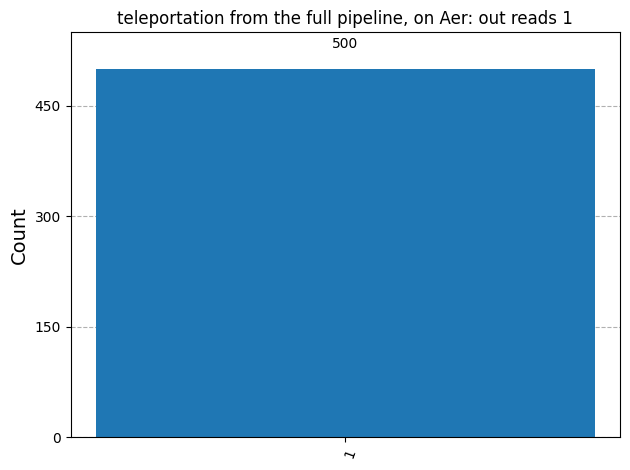

In [18]:
plot_histogram(out_marginal(counts), title="teleportation from the full pipeline, on Aer: out reads 1")


## The same teleportation on real IBM hardware
The first cell can queue a fresh live job on your IBM account; the cell below always shows the saved real-backend result, so the demo holds even if the live job is still queued.

In [ ]:
# Live hardware run (optional). Flip SUBMIT_LIVE to True to queue a fresh teleportation job on
# your IBM account, using your locally saved credentials. With SUBMIT_LIVE = False (default) nothing
# is queued, so Run All is safe and the saved result below is shown. Waits up to WAIT_SECONDS, then
# defers to the saved JSON if the job is still in the queue.
SUBMIT_LIVE = False
WAIT_SECONDS = 180

import os, re, json, time
HW  = str(REPO_ROOT / "demo" / "hw_teleport_counts.json")
JOB = str(REPO_ROOT / "demo" / "hw_teleport_job.txt")

if SUBMIT_LIVE:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

    # the exact program, with IBM's accepted (creg, value) condition in place of the uint[32] cast
    hw_src = re.sub(
        r"expr\.equal\(expr\.cast\((\w+), types\.Uint\(32\)\), expr\.cast\((\w+), types\.Uint\(32\)\)\)",
        r"(\1, \2)", tele_src)
    _, qc_hw = run_source(hw_src)

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=qc_hw.num_qubits)
    # or pin the one the saved result used: backend = service.backend("ibm_marrakesh")
    isa = generate_preset_pass_manager(optimization_level=1, backend=backend).run(qc_hw)
    job = Sampler(mode=backend).run([isa], shots=2000)
    open(JOB, "w").write(job.job_id())
    print(f"queued {job.job_id()} on {backend.name}; waiting up to {WAIT_SECONDS}s ...")

    t0 = time.time()
    while not job.done() and time.time() - t0 < WAIT_SECONDS:
        time.sleep(5)

    if job.done():
        # the teleported qubit's register is the last one added, works for the modeler program and the built-in model
        _res_reg = qc_hw.cregs[-1].name
        live = getattr(job.result()[0].data, _res_reg).get_counts()
        json.dump(live, open(HW, "w"))
        plot_histogram(live, title=f"teleportation LIVE on {backend.name} (out qubit)")
    else:
        print(f"still queued after {WAIT_SECONDS}s; the saved result below stands. "
              f"Check the job later via the id in {os.path.basename(JOB)}.")
else:
    print("SUBMIT_LIVE is False, nothing queued. The saved hardware result below is shown.")

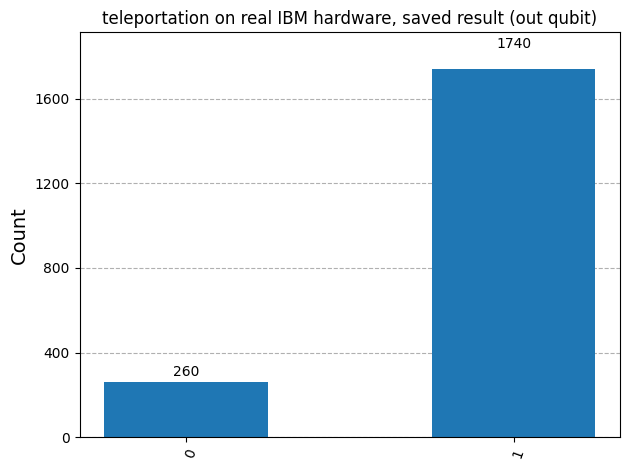

In [20]:
import os, json
HW = str(REPO_ROOT / "demo" / "hw_teleport_counts.json")
# Fallback: the saved real-backend result (ibm_marrakesh). Always available, even if the live cell
# above is still queued. This is what shows on a plain Run All.
assert os.path.exists(HW), "no saved hardware result yet"
plot_histogram(json.load(open(HW)), title="teleportation on real IBM hardware, saved result (out qubit)")

## QAOA, a variational algorithm

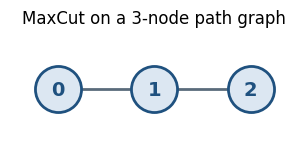

In [21]:
import matplotlib.pyplot as plt

# the MaxCut problem QAOA solves: a 3-node path graph, edges 0-1 and 1-2
fig, ax = plt.subplots(figsize=(4, 1.5))
pos = {0: (0, 0), 1: (1, 0), 2: (2, 0)}
for a, b in [(0, 1), (1, 2)]:
    ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], color="#5a6b7b", lw=2, zorder=1)
for n, (x, y) in pos.items():
    ax.scatter([x], [y], s=1100, color="#dce7f2", edgecolors="#1F517F", linewidths=2, zorder=2)
    ax.text(x, y, str(n), ha="center", va="center", fontsize=14, fontweight="bold", color="#1F517F", zorder=3)
ax.set_title("MaxCut on a 3-node path graph")
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.6, 0.6)
ax.set_aspect("equal"); ax.axis("off")
plt.show()

In [22]:
qaoa = """
OPENQASM 3.0;
include "stdgates.inc";
input angle gamma; input angle beta;
qubit[3] q; bit[3] c;
h q[0]; h q[1]; h q[2];
cx q[0], q[1]; rz(gamma) q[1]; cx q[0], q[1];
cx q[1], q[2]; rz(gamma) q[2]; cx q[1], q[2];
rx(beta) q[0]; rx(beta) q[1]; rx(beta) q[2];
measure q -> c;
"""
print(to_qiskit(qaoa))

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
qc = QuantumCircuit()
inputs_list = []
gamma = Parameter('gamma')
beta = Parameter('beta')
q = QuantumRegister(3, 'q')
qc.add_register(q)
c = ClassicalRegister(3, 'c')
qc.add_register(c)
qc.h(q[0])
qc.h(q[1])
qc.h(q[2])
qc.cx(q[0], q[1])
qc.rz(gamma, q[1])
qc.cx(q[0], q[1])
qc.cx(q[1], q[2])
qc.rz(gamma, q[2])
qc.cx(q[1], q[2])
qc.rx(beta, q[0])
qc.rx(beta, q[1])
qc.rx(beta, q[2])
qc.measure(q, c)
' --- EXECUTION ---'
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
print(compiled_circuit)
'Note: External parameter bindings detected. Provide explicit values before execution.'


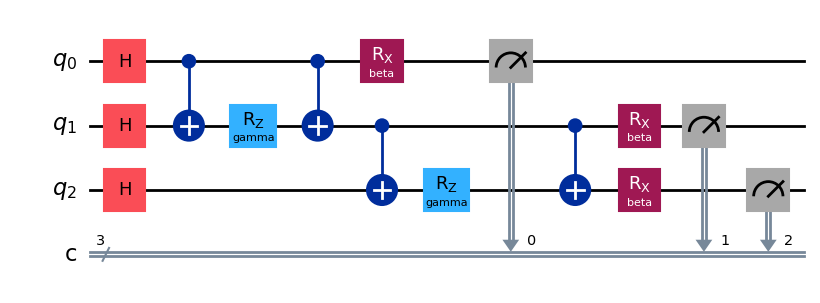

In [23]:
_, qc = run_source(to_qiskit(qaoa))
qc.draw("mpl")

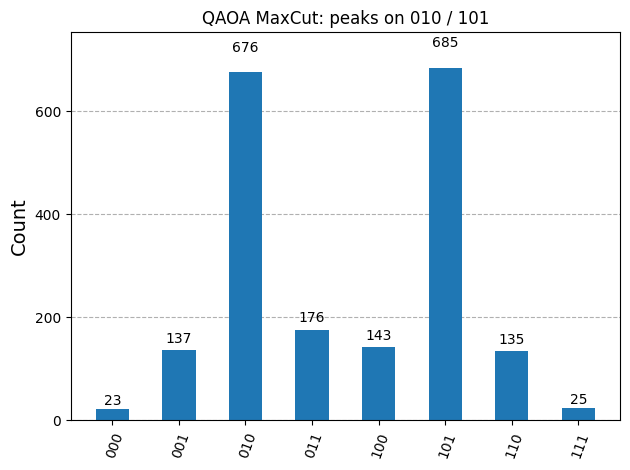

In [24]:
from qiskit_aer import AerSimulator

bound = qc.assign_parameters({p: (1.0996 if p.name == "gamma" else 2.3562) for p in qc.parameters})
counts = AerSimulator(seed_simulator=42).run(bound, shots=2000).result().get_counts()
plot_histogram(counts, title="QAOA MaxCut: peaks on 010 / 101")

## Error correction: a 3-qubit bit-flip code, recovered in-circuit
A logical `|1>` is encoded across three qubits. A bit-flip strikes `q[1]`. Two ancillas read the error syndrome, and a measurement-driven recovery flips the right qubit back, all inside one execution. The same exporter and the same measurement-driven control as the teleportation correction, here scaled toward fault tolerance.

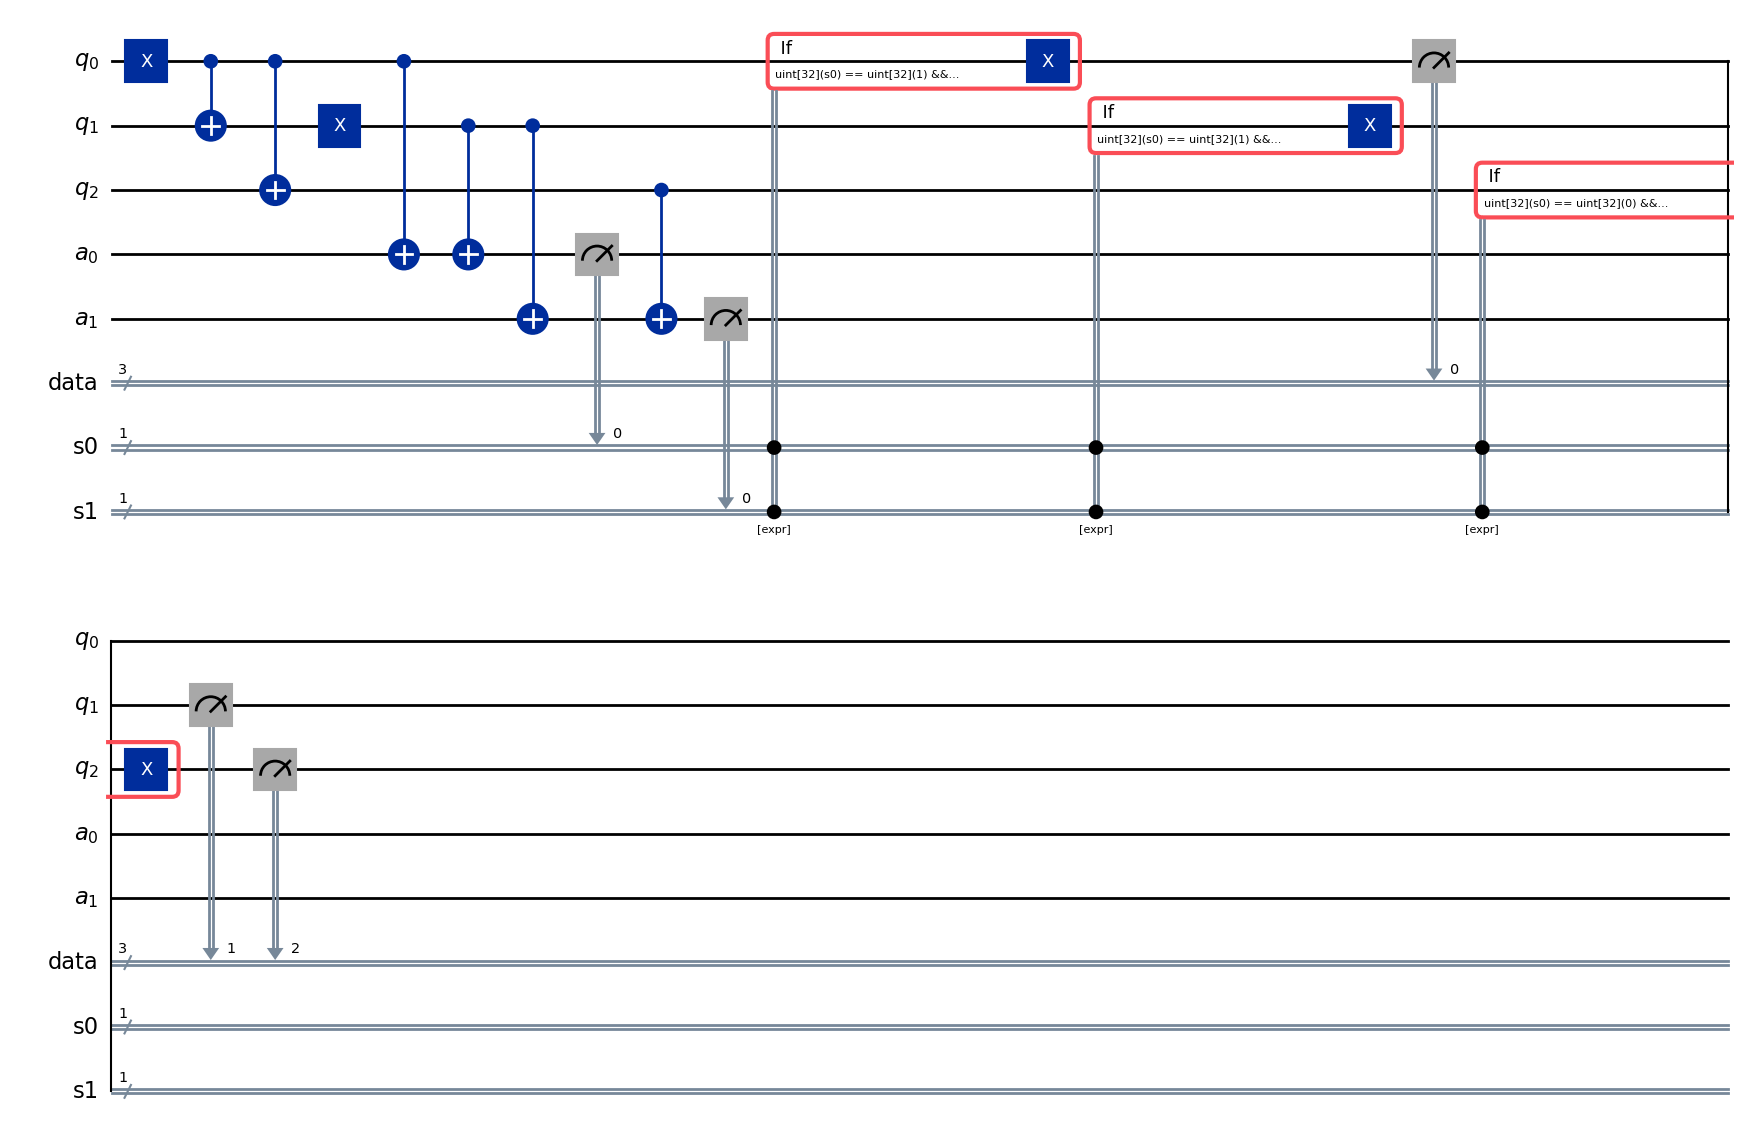

In [25]:
recovery = """if (s0 == 1 && s1 == 0) { x q[0]; }
if (s0 == 1 && s1 == 1) { x q[1]; }
if (s0 == 0 && s1 == 1) { x q[2]; }"""

bitflip = f"""
OPENQASM 3.0;
include "stdgates.inc";
qubit[3] q;
qubit[2] a;
bit[3] data;
bit s0;
bit s1;

// encode a logical |1> across three qubits
x q[0];
cx q[0], q[1];
cx q[0], q[2];

// a bit-flip error strikes q[1]
x q[1];

// read the error syndrome onto two ancillas
cx q[0], a[0];
cx q[1], a[0];
cx q[1], a[1];
cx q[2], a[1];
s0 = measure a[0];
s1 = measure a[1];

// measurement-driven recovery: flip the qubit the syndrome points to
{recovery}

data = measure q;
"""

counts_rec, qc = run_source(to_qiskit(bitflip))
qc.draw("mpl")

In [26]:
# the exporter turns each syndrome condition into a Qiskit if_test
print(to_qiskit(bitflip))

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.classical import types
from qiskit_aer import AerSimulator
import qiskit.circuit.classical.expr as expr
qc = QuantumCircuit()
inputs_list = []
q = QuantumRegister(3, 'q')
qc.add_register(q)
a = QuantumRegister(2, 'a')
qc.add_register(a)
data = ClassicalRegister(3, 'data')
qc.add_register(data)
s0 = ClassicalRegister(1, 's0')
qc.add_register(s0)
s1 = ClassicalRegister(1, 's1')
qc.add_register(s1)
qc.x(q[0])
qc.cx(q[0], q[1])
qc.cx(q[0], q[2])
qc.x(q[1])
qc.cx(q[0], a[0])
qc.cx(q[1], a[0])
qc.cx(q[1], a[1])
qc.cx(q[2], a[1])
qc.measure(a[0], s0)
qc.measure(a[1], s1)
with qc.if_test(expr.logic_and(expr.equal(expr.cast(s0, types.Uint(32)), expr.cast(1, types.Uint(32))), expr.equal(expr.cast(s1, types.Uint(32)), expr.cast(0, types.Uint(32))))):
    qc.x(q[0])
with qc.if_test(expr.logic_and(expr.equal(expr.cast(s0, types.Uint(32)), expr.cast(1, types.Uint(32))), expr.equal(expr.cast(s1, types

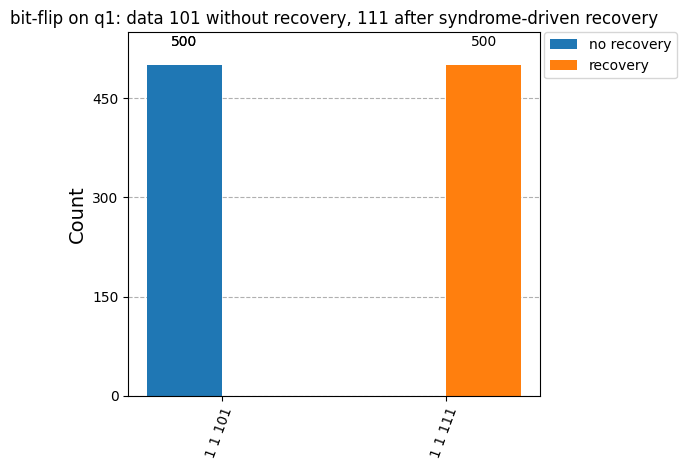

In [27]:
# same program with the recovery removed: the bit-flip on q1 survives as 101
counts_norec, _ = run_source(to_qiskit(bitflip.replace(recovery, "")))
plot_histogram([counts_norec, counts_rec], legend=["no recovery", "recovery"],
               title="bit-flip on q1: data 101 without recovery, 111 after syndrome-driven recovery")